# Sleep Health and Lifestyle Analysis (Simple Version)

Just run the cells **one by one from top to bottom** (click a cell, press **Shift + Enter**).
Or use **Runtime → Run all**.

| Step | What it does |
|---|---|
| 1 | Data Loading & Reading |
| 2 | Data Acquisition & Filtering |
| 3 | Data Extraction |
| 4 | Data Validation & Cleaning |
| 5 | Data Aggregation & Representation |
| 6 | Data Analysis |
| 7 | Data Visualization |
| 8 | Results & Interpretation |


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


---
# Step 1: Data Loading & Reading

Run the cell below, click **Choose Files**, and pick your CSV file.
You do **not** need to type the file name.


In [5]:
from google.colab import files
uploaded = files.upload()                    # click "Choose Files" and pick your CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df_raw = df.copy()                           # backup of the original data
df.head()


Saving Sleep_Health_and_lifestyle_dataset_MESSY_v2.csv to Sleep_Health_and_lifestyle_dataset_MESSY_v2.csv


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,239.0,F,39.0,engineer,3.5,6.0,26.0,4.0,Overweight,160/100,77.0,8867.0,NONE
1,115.0,Female,200.0,Doctor,3.2,4.0,79.0,4.0,OVERWEIGHT,05/70,73.0,13985.0,NaN
2,108.0,NaN,35.0,Accountant,9.2,9.0,NaN,3.0,Normal,120/80,60.0,12810.0,NaN
3,235.0,NaN,37.0,Software Engineer,4.8,NaN,83.0,1.0,Underweight,120/80,NaN,NaN,NaN
4,221.0,Female,62.0,Accountant,4.6,3.0,17.0,1.0,NaN,160/100,77.0,1700.0,Insomnia


*Using PyCharm instead of Colab?* Replace the first 3 lines above with:
`df = pd.read_csv("your_file_name.csv")`


In [6]:
print("Rows and columns:", df.shape)
df.info()


Rows and columns: (396, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                392 non-null    float64
 1   Gender                   343 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               360 non-null    object 
 4   Sleep Duration           370 non-null    float64
 5   Quality of Sleep         381 non-null    float64
 6   Physical Activity Level  381 non-null    float64
 7   Stress Level             373 non-null    float64
 8   BMI Category             347 non-null    object 
 9   Blood Pressure           392 non-null    object 
 10  Heart Rate               375 non-null    float64
 11  Daily Steps              376 non-null    float64
 12  Sleep Disorder           290 non-null    object 
dtypes: float64(8), object(5)
memory usage: 40.3+ KB


In [7]:
# How many empty (missing) values in each column?
df.isnull().sum()


,0
Person ID,4
Gender,53
Age,22
Occupation,36
Sleep Duration,26
Quality of Sleep,15
Physical Activity Level,15
Stress Level,23
BMI Category,49
Blood Pressure,4


In [8]:
# Quick statistics for every column
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Person ID,392.0,NaN,NaN,NaN,189.290816,110.383763,1.0,94.75,189.5,284.25,380.0
Gender,343,8,Male,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,374.0,NaN,NaN,NaN,44.914439,32.087149,-10.0,28.0,39.5,56.75,200.0
Occupation,360,13,Software Engineer,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Duration,370.0,NaN,NaN,NaN,6.928919,3.063192,3.0,4.825,6.6,8.275,20.9
Quality of Sleep,381.0,NaN,NaN,NaN,5.566929,3.759739,-3.0,3.0,5.0,8.0,19.0
Physical Activity Level,381.0,NaN,NaN,NaN,51.895013,55.682649,-20.0,22.0,51.0,75.0,500.0
Stress Level,373.0,NaN,NaN,NaN,5.042895,3.250853,0.0,2.0,5.0,7.0,15.0
BMI Category,347,7,normal,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Pressure,392,9,140/95,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# Step 2: Data Acquisition & Filtering

- Keep only the columns we need
- Remove rows that are completely empty
- Turn number columns into real numbers
- Filter the data (pick only some rows)


In [9]:
columns = ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
           'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure',
           'Heart Rate', 'Daily Steps', 'Sleep Disorder']

df = df[columns]                 # keep only these columns
df = df.dropna(how='all')        # remove completely empty rows
print("Rows left:", len(df))


Rows left: 392


In [10]:
# Make sure number columns are numbers (anything that is not a number becomes empty)
number_columns = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps']

for col in number_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(col, ":", df[col].dtype)


Age : float64
Sleep Duration : float64
Quality of Sleep : float64
Physical Activity Level : float64
Stress Level : float64
Heart Rate : float64
Daily Steps : float64


In [11]:
# Filtering = keeping only the rows that match a condition
short_sleepers = df[df['Sleep Duration'] < 6]
high_stress = df[df['Stress Level'] >= 7]
both = df[(df['Sleep Duration'] < 6) & (df['Stress Level'] >= 7)]

print("People sleeping less than 6 hours:", len(short_sleepers))
print("People with stress level 7 or more:", len(high_stress))
print("People with BOTH:", len(both))

both[['Person ID', 'Occupation', 'Sleep Duration', 'Stress Level']].head()


People sleeping less than 6 hours: 157
People with stress level 7 or more: 124
People with BOTH: 44


,Person ID,Occupation,Sleep Duration,Stress Level
16,349.0,Sales Representative,4.3,9.0
20,128.0,Salesperson,5.5,7.0
34,75.0,Doctor,3.4,7.0
45,118.0,Accountant,5.2,7.0
52,334.0,DOCTOR,5.7,8.0


---
# Step 3: Data Extraction

Take information **out of** existing columns and make new columns.

Blood Pressure is text like `126/83`. We split it into two number columns.


In [12]:
# Pull the two numbers out of the Blood Pressure text
bp = df['Blood Pressure'].astype(str).str.extract(r'(\d+)\D+(\d+)')
df['Systolic_BP'] = pd.to_numeric(bp[0])
df['Diastolic_BP'] = pd.to_numeric(bp[1])

df[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP']].head()


,Blood Pressure,Systolic_BP,Diastolic_BP
0,160/100,160,100
1,05/70,5,70
2,120/80,120,80
3,120/80,120,80
4,160/100,160,100


In [13]:
# Make two new group columns
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 59, 100],
                         labels=['18-29', '30-39', '40-49', '50-59', '60+'])

df['Sleep_Category'] = pd.cut(df['Sleep Duration'], bins=[0, 6, 8, 24],
                              labels=['Short (6h or less)', 'Normal (6-8h)', 'Long (over 8h)'])

df[['Age', 'Age_Group', 'Sleep Duration', 'Sleep_Category']].head()


,Age,Age_Group,Sleep Duration,Sleep_Category
0,39.0,30-39,3.5,Short (6h or less)
1,200.0,NaN,3.2,Short (6h or less)
2,35.0,30-39,9.2,Long (over 8h)
3,37.0,30-39,4.8,Short (6h or less)
4,62.0,60+,4.6,Short (6h or less)


---
# Step 4: Data Validation & Cleaning

Real data is messy. Here we fix it, step by step.


### 4.1 Fix the text (extra spaces, capital letters, short forms)

In [14]:
df['Gender'] = df['Gender'].str.strip().str.title()
df['Gender'] = df['Gender'].replace({'M': 'Male', 'F': 'Female'})

df['Occupation'] = df['Occupation'].str.strip().str.title()
df['Occupation'] = df['Occupation'].replace('Unknown', np.nan)

df['BMI Category'] = df['BMI Category'].str.strip().str.title()
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

df['Sleep Disorder'] = df['Sleep Disorder'].str.strip().str.title()
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')   # empty means "no disorder" in this dataset

# Check: these should now show only clean labels
print(df['Gender'].value_counts())
print()
print(df['BMI Category'].value_counts())
print()
print(df['Sleep Disorder'].value_counts())


Gender
Male      183
Female    160
Name: count, dtype: int64

BMI Category
Normal         149
Overweight      91
Underweight     54
Obese           53
Name: count, dtype: int64

Sleep Disorder
None           187
Sleep Apnea    110
Insomnia        95
Name: count, dtype: int64


### 4.2 Remove impossible values

`.where(...)` keeps a value only if it is in a sensible range. Otherwise it becomes empty (NaN).
For example, an age of 200 or a stress level of 25 is not possible.


In [15]:
missing_before = df.isnull().sum().sum()

df['Age'] = df['Age'].where(df['Age'].between(18, 100))
df['Sleep Duration'] = df['Sleep Duration'].where(df['Sleep Duration'].between(2, 14))
df['Quality of Sleep'] = df['Quality of Sleep'].where(df['Quality of Sleep'].between(1, 10))
df['Physical Activity Level'] = df['Physical Activity Level'].where(df['Physical Activity Level'].between(0, 300))
df['Stress Level'] = df['Stress Level'].where(df['Stress Level'].between(1, 10))
df['Heart Rate'] = df['Heart Rate'].where(df['Heart Rate'].between(40, 150))
df['Daily Steps'] = df['Daily Steps'].where(df['Daily Steps'].between(0, 40000))
df['Systolic_BP'] = df['Systolic_BP'].where(df['Systolic_BP'].between(70, 250))
df['Diastolic_BP'] = df['Diastolic_BP'].where(df['Diastolic_BP'].between(40, 150))

# If one blood pressure number is bad, remove both
bad_bp = df['Systolic_BP'].isnull() | df['Diastolic_BP'].isnull()
df.loc[bad_bp, ['Systolic_BP', 'Diastolic_BP']] = np.nan

missing_after = df.isnull().sum().sum()
print("Impossible values removed:", missing_after - missing_before)


Impossible values removed: 243


### 4.3 Remove duplicates

In [16]:
rows_before = len(df)

df = df.drop_duplicates()                        # rows that are exactly the same
df = df.drop_duplicates(subset='Person ID')      # same Person ID appearing twice

print("Duplicate rows removed:", rows_before - len(df))


Duplicate rows removed: 22


### 4.4 Build the group columns again (now that the data is clean)

In [17]:
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 59, 100],
                         labels=['18-29', '30-39', '40-49', '50-59', '60+'])

df['Sleep_Category'] = pd.cut(df['Sleep Duration'], bins=[0, 6, 8, 24],
                              labels=['Short (6h or less)', 'Normal (6-8h)', 'Long (over 8h)'])
print(df['Sleep_Category'].value_counts())


Sleep_Category
Short (6h or less)    150
Normal (6-8h)         101
Long (over 8h)         83
Name: count, dtype: int64


### 4.5 Check the result

In [18]:
print("Rows in original file:", len(df_raw))
print("Rows after cleaning   :", len(df))
print()
print("Empty values left in each column:")
print(df.isnull().sum())


Rows in original file: 396
Rows after cleaning   : 370

Empty values left in each column:
Person ID                   0
Gender                     46
Age                        37
Occupation                 30
Sleep Duration             36
Quality of Sleep           39
Physical Activity Level    28
Stress Level               45
BMI Category               41
Blood Pressure              0
Heart Rate                 37
Daily Steps                28
Sleep Disorder              0
Systolic_BP                45
Diastolic_BP               45
Age_Group                  37
Sleep_Category             36
dtype: int64


> Empty values that remain are **not filled in**. Each calculation below simply skips them.

---
# Step 5: Data Aggregation & Representation

Summarise the data into small tables.


In [19]:
# Average by occupation
summary = df.groupby('Occupation')[['Sleep Duration', 'Stress Level', 'Daily Steps']].mean().round(2)
summary['People'] = df['Occupation'].value_counts()      # how many people in each group
summary.sort_values('Sleep Duration')


,Sleep Duration,Stress Level,Daily Steps,People
Occupation,,,,
Sales Representative,5.65,6.00,7872.05,24
Scientist,5.83,5.32,9824.89,20
Teacher,6.01,5.29,9635.54,24
Software Engineer,6.19,4.58,6535.08,42
Nurse,6.26,3.65,6327.17,26
Salesperson,6.46,5.38,6916.00,25
Doctor,6.51,4.83,8249.24,48
Accountant,6.57,4.42,7557.83,25
Lawyer,6.62,4.52,8639.96,31


In [22]:
# Average sleep by occupation AND gender
pd.pivot_table(df, values='Sleep Duration', index='Occupation', columns='Gender', aggfunc='mean').round(2)


Gender,Female,Male
Occupation,,
Accountant,6.42,6.62
Doctor,6.59,6.37
Engineer,7.19,7.29
Lawyer,5.89,6.42
Manager,6.16,6.77
Nurse,5.52,6.46
Sales Representative,5.15,5.78
Salesperson,6.04,6.58
Scientist,5.30,6.07


In [23]:
# Count of sleep disorders in each BMI group
pd.crosstab(df['BMI Category'], df['Sleep Disorder'])


Sleep Disorder,Insomnia,None,Sleep Apnea
BMI Category,,,
Normal,29,70,43
Obese,8,28,15
Overweight,26,41,20
Underweight,12,22,15


In [24]:
# Average by gender and BMI
df.groupby(['Gender', 'BMI Category'])[['Sleep Duration', 'Stress Level']].mean().round(2)


Sleep Duration  Stress Level
Gender BMI Category                              
Female Normal                  5.97          4.22
       Obese                   6.47          4.22
       Overweight              6.08          4.89
       Underweight             6.49          4.84
Male   Normal                  6.37          5.37
       Obese                   7.02          4.53
       Overweight              6.81          5.08
       Underweight             5.44          5.50

---
# Step 6: Data Analysis

**How to read the p-value:** if `p` is **below 0.05**, the result is unlikely to be just chance ("significant"). If it prints `0.0`, that means extremely small, so very significant.


In [31]:
# Correlation: numbers close to -1 or +1 mean a strong link, close to 0 means no link
cols = ['Sleep Duration', 'Quality of Sleep', 'Stress Level',
        'Physical Activity Level', 'Heart Rate', 'Daily Steps']
df[cols].corr().round(2)


,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Heart Rate,Daily Steps
Sleep Duration,1.00,-0.16,0.07,-0.00,-0.00,-0.03
Quality of Sleep,-0.16,1.00,-0.01,0.03,0.00,-0.03
Stress Level,0.07,-0.01,1.00,-0.05,0.10,-0.04
Physical Activity Level,-0.00,0.03,-0.05,1.00,0.08,-0.05
Heart Rate,-0.00,0.00,0.10,0.08,1.00,0.04
Daily Steps,-0.03,-0.03,-0.04,-0.05,0.04,1.00


In [26]:
# Stress vs Sleep Duration
d = df[['Stress Level', 'Sleep Duration']].dropna()
r_stress, p_stress = stats.pearsonr(d['Stress Level'], d['Sleep Duration'])
print("Stress vs Sleep Duration -> r =", round(r_stress, 2), ", p =", round(p_stress, 4))

# Physical Activity vs Quality of Sleep
d = df[['Physical Activity Level', 'Quality of Sleep']].dropna()
r_activity, p_activity = stats.pearsonr(d['Physical Activity Level'], d['Quality of Sleep'])
print("Activity vs Sleep Quality -> r =", round(r_activity, 2), ", p =", round(p_activity, 4))


Stress vs Sleep Duration -> r = 0.07 , p = 0.2237
Activity vs Sleep Quality -> r = 0.03 , p = 0.6427


In [27]:
# Does sleep duration differ between occupations? (ANOVA)
# Only occupations with 10 or more people are used, tiny groups are not reliable.
groups = [g['Sleep Duration'].dropna() for name, g in df.groupby('Occupation') if len(g) >= 10]
f_value, p_anova = stats.f_oneway(*groups)
print("ANOVA: Sleep Duration across occupations -> p =", round(p_anova, 4))


ANOVA: Sleep Duration across occupations -> p = 0.2086


In [29]:
# Are sleep disorders linked to BMI category? (Chi-square test)
table = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])
chi2, p_chi, dof, expected = stats.chi2_contingency(table)
print("Chi-square: Sleep Disorder vs BMI Category -> p =", round(p_chi, 4))


Chi-square: Sleep Disorder vs BMI Category -> p = 0.5137


In [30]:
# Simple prediction line: how much does sleep change for each stress point?
d = df[['Stress Level', 'Sleep Duration']].dropna()
line = stats.linregress(d['Stress Level'], d['Sleep Duration'])
print("Each +1 stress point changes sleep by", round(line.slope, 2), "hours")
print("R-squared (how much of sleep this explains):", round(line.rvalue ** 2, 2))


Each +1 stress point changes sleep by 0.05 hours
R-squared (how much of sleep this explains): 0.01


---
# Step 7: Data Visualization


### 7.1 Distributions (how the values are spread out)

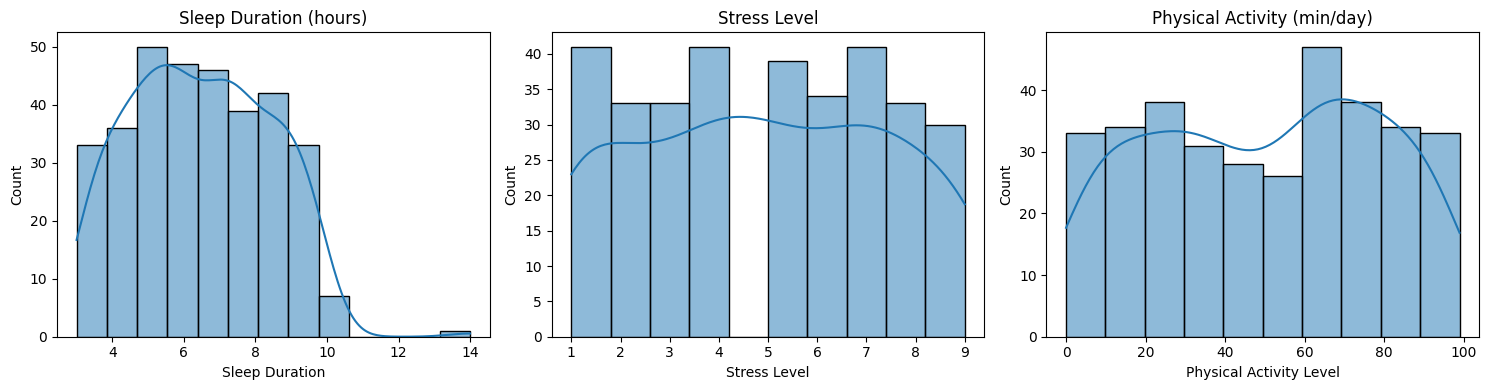

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Sleep Duration'], kde=True, ax=axes[0])
axes[0].set_title('Sleep Duration (hours)')

sns.histplot(df['Stress Level'], kde=True, ax=axes[1])
axes[1].set_title('Stress Level')

sns.histplot(df['Physical Activity Level'], kde=True, ax=axes[2])
axes[2].set_title('Physical Activity (min/day)')

plt.tight_layout()
plt.show()


### 7.2 Sleep duration by occupation

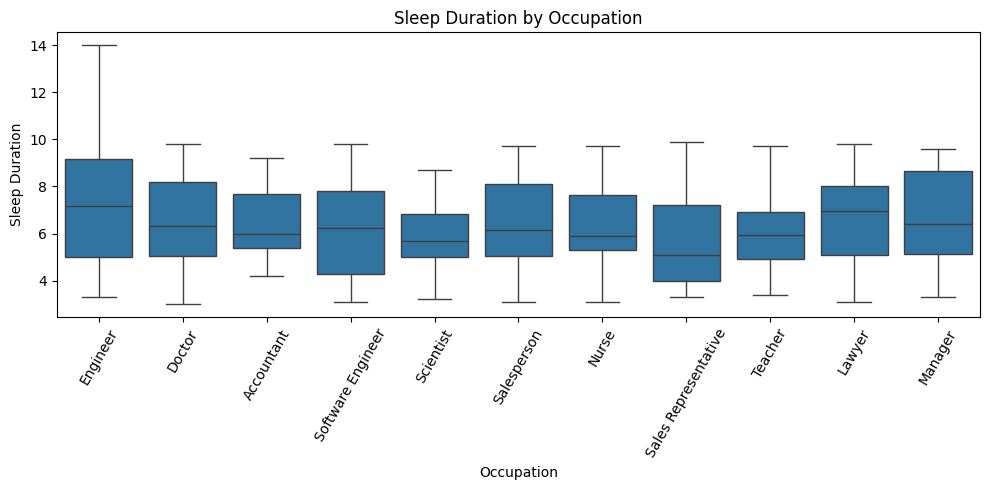

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Occupation', y='Sleep Duration')
plt.xticks(rotation=60)
plt.title('Sleep Duration by Occupation')
plt.tight_layout()
plt.show()


### 7.3 Correlation heatmap

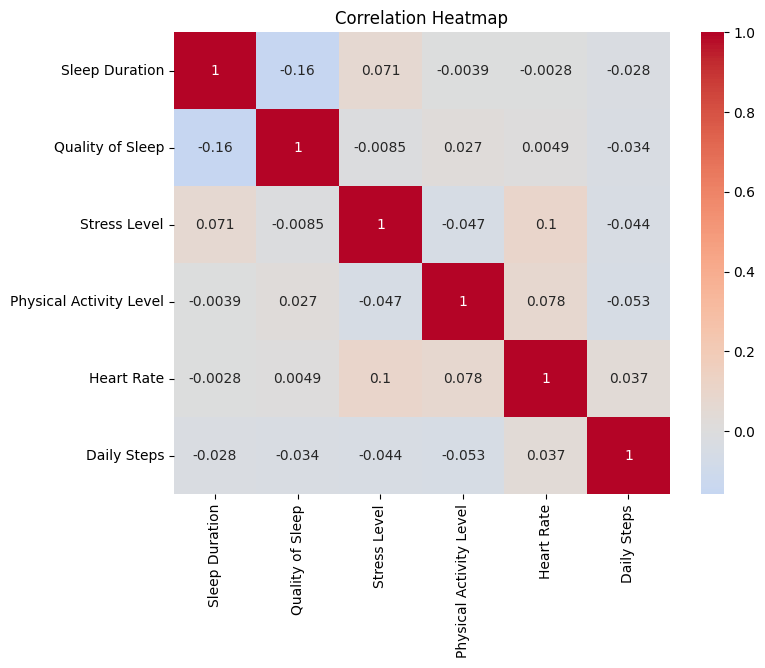

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


### 7.4 Stress vs sleep, and activity vs sleep quality

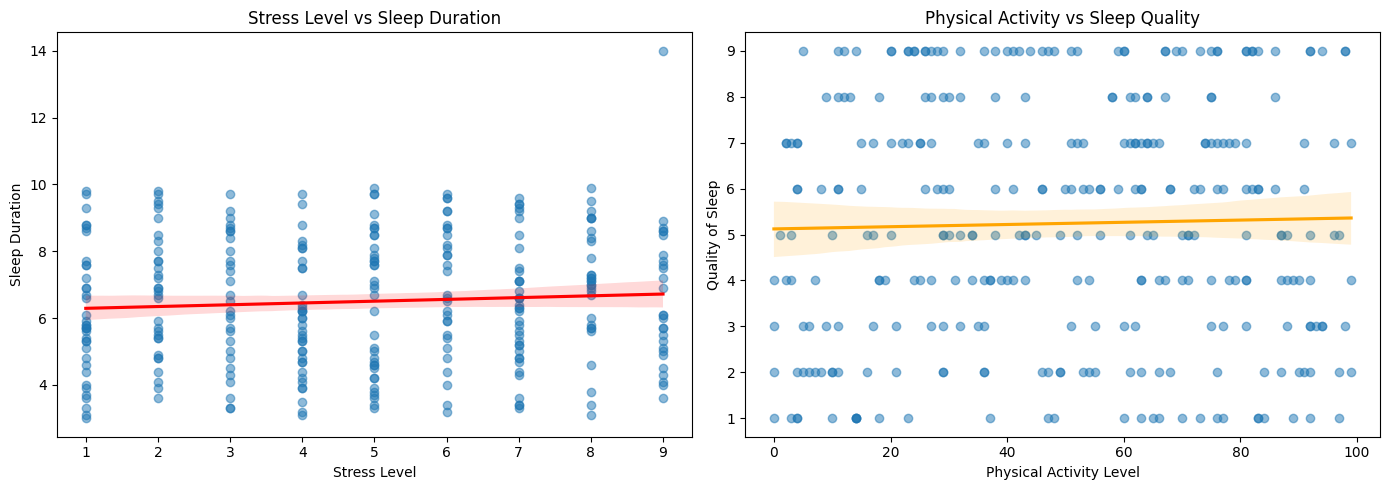

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='Stress Level', y='Sleep Duration', ax=axes[0],
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
axes[0].set_title('Stress Level vs Sleep Duration')

sns.regplot(data=df, x='Physical Activity Level', y='Quality of Sleep', ax=axes[1],
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'orange'})
axes[1].set_title('Physical Activity vs Sleep Quality')

plt.tight_layout()
plt.show()


### 7.5 Average stress by occupation

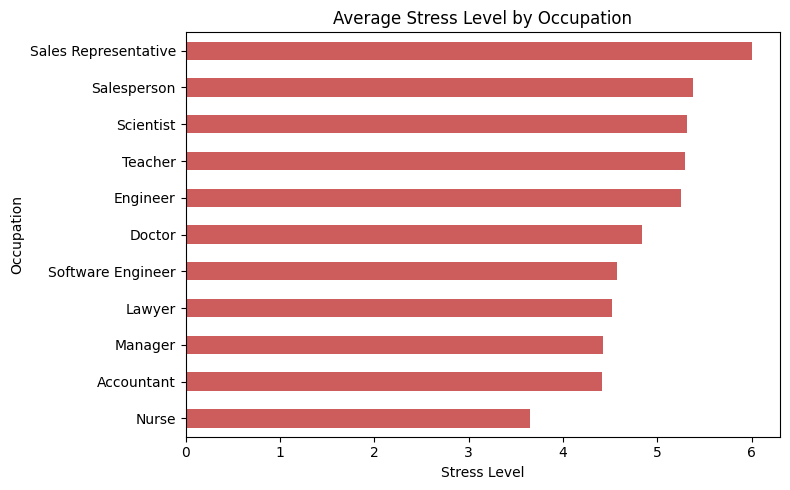

In [ ]:
df.groupby('Occupation')['Stress Level'].mean().sort_values().plot(kind='barh', figsize=(8, 5), color='indianred')
plt.title('Average Stress Level by Occupation')
plt.xlabel('Stress Level')
plt.tight_layout()
plt.show()


### 7.6 Sleep disorders by occupation (percent)

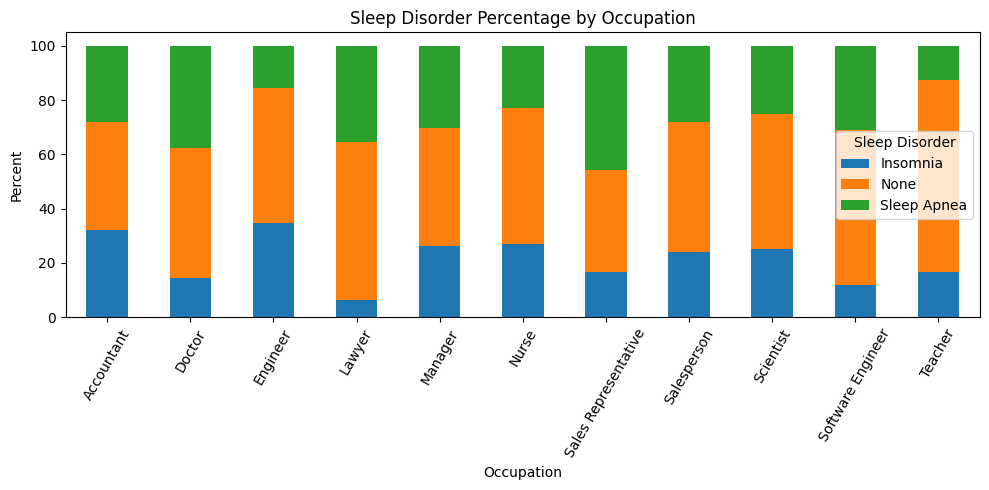

In [ ]:
percent = pd.crosstab(df['Occupation'], df['Sleep Disorder'], normalize='index') * 100
percent.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Sleep Disorder Percentage by Occupation')
plt.ylabel('Percent')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


---
# Step 8: Results & Interpretation

The sentences below are **written by the code from your actual numbers**, so they match your data.


In [32]:
print("Rows used:", len(df), "out of", len(df_raw), "in the original file")
print()

# 1. Stress and sleep
print("1) Stress vs Sleep Duration (r =", round(r_stress, 2), ", p =", round(p_stress, 4), ")")
if p_stress >= 0.05:
    print("   No reliable link found between stress and sleep duration.")
elif r_stress < 0:
    print("   Higher stress goes with SHORTER sleep. This is significant.")
else:
    print("   Higher stress goes with LONGER sleep. This is significant.")
print()

# 2. Activity and sleep quality
print("2) Activity vs Sleep Quality (r =", round(r_activity, 2), ", p =", round(p_activity, 4), ")")
if p_activity >= 0.05:
    print("   No reliable link found between activity and sleep quality.")
elif r_activity > 0:
    print("   More activity goes with BETTER sleep quality. This is significant.")
else:
    print("   More activity goes with WORSE sleep quality. This is significant.")
print()

# 3. Occupations
big = summary[summary['People'] >= 10]
print("3) Occupations (only groups with 10+ people)")
print("   Shortest sleep :", big['Sleep Duration'].idxmin(), "-", big['Sleep Duration'].min(), "hours")
print("   Longest sleep  :", big['Sleep Duration'].idxmax(), "-", big['Sleep Duration'].max(), "hours")
print("   Most stressed  :", big['Stress Level'].idxmax(), "-", big['Stress Level'].max(), "out of 10")
if p_anova < 0.05:
    print("   The sleep difference between occupations is significant (p =", round(p_anova, 4), ").")
else:
    print("   The sleep difference between occupations could just be chance (p =", round(p_anova, 4), ").")
print()

# 4. Sleep disorders
print("4) Sleep disorders")
has_disorder = (df['Sleep Disorder'] != 'None').mean() * 100
print("   People with a sleep disorder:", round(has_disorder, 1), "%")
if p_chi < 0.05:
    print("   Sleep disorder IS linked to BMI category (p =", round(p_chi, 4), ").")
else:
    print("   No reliable link between sleep disorder and BMI category (p =", round(p_chi, 4), ").")
print()

# 5. Prediction
print("5) Each +1 stress point changes sleep by", round(line.slope, 2), "hours.")
print("   Stress explains about", round(line.rvalue ** 2 * 100), "% of the differences in sleep duration.")


Rows used: 370 out of 396 in the original file

1) Stress vs Sleep Duration (r = 0.07 , p = 0.2237 )
   No reliable link found between stress and sleep duration.

2) Activity vs Sleep Quality (r = 0.03 , p = 0.6427 )
   No reliable link found between activity and sleep quality.

3) Occupations (only groups with 10+ people)
   Shortest sleep : Sales Representative - 5.65 hours
   Longest sleep  : Engineer - 7.12 hours
   Most stressed  : Sales Representative - 6.0 out of 10
   The sleep difference between occupations could just be chance (p = 0.2086 ).

4) Sleep disorders
   People with a sleep disorder: 51.4 %
   No reliable link between sleep disorder and BMI category (p = 0.5137 ).

5) Each +1 stress point changes sleep by 0.05 hours.
   Stress explains about 1 % of the differences in sleep duration.


### Things to remember (limitations)

- **A link is not proof of cause.** Stress may affect sleep, or sleep may affect stress.
- **The dataset is small.** Small occupation groups (under 10 people) were left out of the tests.
- **This dataset may be made-up (synthetic) data**, so don't treat the results as real-world facts.
- **Empty values were left empty**, not guessed, so some calculations use fewer rows.
- **"Sleep Disorder" empty = "None"** is an assumption we made.
